In [1]:
# -*- coding: utf-8 -*-

# Importing necessary libraries and modules
import numpy as np
from pmutt import parse_formula, constants
from pmutt.statmech import StatMech, presets
from collections import defaultdict
from pgradd.GroupAdd.Library import GroupLibrary
import pandas as pd
from pmutt.io.thermdat import write_thermdat, read_thermdat
from pmutt.empirical.references import Reference, References
import glob
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
import matplotlib.pyplot as plt
from ase.io import read
from pmutt.io import gaussian
from tqdm import tqdm
from tabulate import tabulate
import os
from rdkit.Chem import rdchem
import csv
from ase.io.formats import UnknownFileTypeError

idealgas_defaults = presets['idealgas']

#lib = GroupLibrary.Load('Roel_Ru')
lib = GroupLibrary.Load('BensonGAF')

suspect_list = "./fluorinated_list.csv"
suspect_list_df = pd.read_csv(suspect_list, engine='python', encoding='latin1')

/jet/home/seccles/.conda/envs/myenv/lib/python3.13/site-packages/pgradd/GroupAdd/Library.py:284: UserWarning: GroupLibrary.load(): No property sets defined.
  warn('GroupLibrary.load(): No property sets defined.')


In [2]:
# Step 1: Load SMILES and names directly
# Extract SMILES strings and common names from the input DataFrame into Python lists
SMILES = suspect_list_df["SMILES"].tolist()
Common = suspect_list_df["NAME"].tolist()

# Step 2: Tally functional groups and collect unique groups
# Initialize containers:
# - group_tally: total count of each group across all molecules
# - group_set: tracks which groups have been seen so far
# - Groups: ordered list of unique group names (preserves discovery order)
group_tally = defaultdict(int)
group_set = set()
Groups = []

# Loop through each SMILES string and generate functional group descriptors
for smile in tqdm(SMILES, desc="Generating descriptors"):
    # Handle special cases for atomic hydrogen or fluorine
    if smile == 'H':
        descriptors = defaultdict(int, {'H': 1})
    elif smile == 'F':
        descriptors = defaultdict(int, {'F': 1})
    else:
        # Compute descriptors using the library; skip molecule if it errors
        try:
            descriptors = lib.GetDescriptors(smile)
        except Exception as e:
            print(f'Error getting descriptors for {smile}: {e}')
            continue

    # Add new groups to the master list and update global tallies
    for gr, count in descriptors.items():
        if gr not in group_set:
            Groups.append(gr)      # preserve discovery order
            group_set.add(gr)
        group_tally[gr] += count   # accumulate total counts across dataset

# Step 3: Precompute group index mapping
# Create a dictionary mapping each group name to its column index in the matrix
group_to_index = {group: idx for idx, group in enumerate(Groups)}

# Step 4: Initialize and populate the matrix
# Prepare an empty (num_smiles × num_groups) integer matrix
num_smiles = len(SMILES)
num_groups = len(Groups)
group_matrix = np.zeros((num_smiles, num_groups), dtype=int)

# Fill the matrix row-by-row with descriptor counts
for i, smile in tqdm(enumerate(SMILES), total=num_smiles, desc="Populating group matrix"):
    # Recompute descriptors for each molecule (same logic as above)
    if smile == 'H':
        descriptors = defaultdict(int, {'H': 1})
    elif smile == 'F':
        descriptors = defaultdict(int, {'F': 1})
    else:
        try:
            descriptors = lib.GetDescriptors(smile)
        except Exception as e:
            print(f'Error getting descriptors for {smile}: {e}')
            continue

    # Insert descriptor counts into the correct matrix columns
    for group, count in descriptors.items():
        if group in group_to_index:
            group_index = group_to_index[group]
            group_matrix[i, group_index] = count

# Step 5: Create DataFrame and save
# Convert the matrix into a labeled DataFrame with SMILES as index and groups as columns
group_matrix_df = pd.DataFrame(group_matrix, columns=Groups, index=SMILES)

# Display the final group matrix
print("\nFinal Group Matrix:")
print(group_matrix_df)

# Save the matrix to CSV for downstream use
group_matrix_df.to_csv("group_matrix_new.csv", index=True, header=True)


Populating group matrix: 100%|██████████| 3068/3068 [00:14<00:00, 211.88it/s]



Final Group Matrix:
                                                C(C)(F)3  F(C)  C(C)2(F)2  \
C(C(F)(F)F)(F)(F)F                                     2     6          0   
C(C(F)(F)F)(C(F)(F)F)(F)F                              2     8          1   
C(C(C(F)(F)F)(F)F)(C(F)(F)F)(F)F                       2    10          2   
C(C(C(F)(F)F)(F)F)(C(C(F)(F)F)(F)F)(F)F                2    12          3   
C(C(C(C(F)(F)F)(F)F)(F)F)(C(C(F)(F)F)(F)F)(F)F         2    14          4   
...                                                  ...   ...        ...   
C(CO)(#C(F))                                           0     0          0   
C(N)(=N(F))(S)                                         0     0          0   
C(C=C(F))(=N)(O)                                       0     0          0   
C(C=C)(#C(F))                                          0     0          0   
C(C(F))(F)(F)([NH3+])                                  0     3          0   

                                                C(C[d]

In [4]:
# Step 1: Define frequency scaling factor for vibrational corrections
freq_scale = 0.975

# Step 2: Locate all reference files in the specified directory
# Uses glob to collect all files under ./log_files/refs/
pattern = './log_files/refs/*.*'
file_list = glob.glob(pattern, recursive=True)

# Step 3: Extract unique molecule base names (strip folder, extension, and handle both / and \)
molecules_names = list({f.split('/')[-1].split('\\')[-1].split('.')[0] for f in file_list})

# Prepare a list to store Reference objects
refs_list = []

# Step 4: Build Reference objects for each molecule
for name in molecules_names:
    # Construct full paths to the .log and .thermdat files
    filename = f'./log_files/refs/{name}.log'

    # Read molecular geometry from Gaussian log file
    mol = read(filename)

    # Read thermdat data (NASA polynomial parameters, etc.)
    thermdat = read_thermdat(f'./log_files/refs/{name}.thermdat')

    # Read vibrational frequencies, apply scaling, and enforce quasi-harmonic 100 cm⁻¹ floor
    freqs = [max(i * freq_scale, 100) for i in gaussian.read_frequencies(filename)]

    # Create a pMuTT Reference object containing all thermochemical reference data
    ref = Reference(
        name=name,                                      # Molecule identifier
        elements=thermdat[0].elements,                  # Elemental composition
        atoms=mol,                                      # Atomic coordinates
        vib_wavenumbers=freqs,                          # Scaled vibrational frequencies
        symmetrynumber=gaussian.read_rot_symmetry_num(filename),  # Rotational symmetry number
        spin=int(gaussian.read_pattern(filename=filename, pattern='Multiplicity = (.*)')),  # Spin multiplicity
        potential_energy=gaussian.read_electronic_and_zpe(filename),  # Electronic + ZPE energy
        T_ref=298.15,                                   # Reference temperature
        HoRT_ref=thermdat[0].get_HoRT(T=300),           # H/RT at 300 K from thermdat
        **idealgas_defaults                             # Default ideal gas parameters
    )

    # Store the completed Reference object
    refs_list.append(ref)

# Step 5: Combine all Reference objects into a References collection
refs = References(references=refs_list)

# Step 6: Format and print the reference energy offset table
# Convert refs.offset (dict of name → offset energy) into a list of tuples for tabulation
offset_data = [(name, offset) for name, offset in refs.offset.items()]

# Define table headers for readability
headers = ["Molecule", "Ref Energy"]

# Print the table in a grid format
print(tabulate(offset_data, headers=headers, tablefmt="grid"))


+------------+-------------------+
| Molecule   |        Ref Energy |
+============+===================+
| Br         |      -2.72682e+06 |
+------------+-------------------+
| C          |  -40340           |
+------------+-------------------+
| Cl         | -487414           |
+------------+-------------------+
| F          | -105612           |
+------------+-------------------+
| H          |    -609.706       |
+------------+-------------------+
| I          | -314557           |
+------------+-------------------+
| N          |  -57963.3         |
+------------+-------------------+
| O          |  -79553.9         |
+------------+-------------------+
| P          | -361453           |
+------------+-------------------+
| S          | -421642           |
+------------+-------------------+


In [5]:
# Step 1: Load SMILES reference table
# Read the CSV containing molecule names and SMILES strings
smiles_df = pd.read_csv("fluorinated_list.csv")

# Normalize names and build lookup dictionary
# Strip whitespace from NAME column and create a mapping NAME → SMILES
smiles_df["NAME"] = smiles_df["NAME"].astype(str).str.strip()
name_to_smiles = dict(zip(smiles_df["NAME"], smiles_df["SMILES"]))

# Convert reference names to a set for fast membership checks
reference_names = set(name_to_smiles.keys())

# Step 2: Define patterns for log file locations
# Each path pattern corresponds to a directory containing Gaussian log files
patterns = [
    '../../CFH_LIST/log_file/*.log',
    './log_files/*.log',
    '../../CFOS_Runs/log_files/*.log',
    '../../CFOSN_Runs/log_files/*.log',
    '../../PClBrI_Runs/log_files/*.log',
    '/ocean/projects/che250025p/seccles/charged_under250/log_file/*.log',
    '../../Low_freq_group_runs1/log_files/*.log',
    '../../Low_freq_group_runs2/log_files/*.log'
]

# Step 3: Collect all matching log files
# Loop through each pattern and accumulate all matching .log files
file_list = []
for pattern in patterns:
    file_list += glob.glob(pattern, recursive=True)

# Step 4: Extract base name before any suffix like "-p2"
# This ensures filenames like "CF3-p2.log" map back to "CF3"
def extract_base_name(filename):
    name = os.path.splitext(os.path.basename(filename))[0]  # remove directory + extension
    return name.split('-')[0].strip()                       # remove suffix after '-'

# Step 5: Match log file names to reference names (no duplicates)
# matched: list of (Name, SMILES, LogFile)
matched = []
used_names = set()

for log_file in file_list:
    base_name = extract_base_name(log_file)

    # Only match if the base name exists in the reference list and hasn't been used yet
    if base_name in reference_names and base_name not in used_names:
        smiles = name_to_smiles[base_name]
        matched.append((base_name, smiles, log_file))
        used_names.add(base_name)

# Step 6: Convert matched data to DataFrame with SMILES
# Create a structured table with columns: Name, SMILES, LogFile
matched_df = pd.DataFrame(matched, columns=["Name", "SMILES", "LogFile"])

# Step 7: Save results to CSV
output_csv = "matched_structures.csv"
matched_df.to_csv(output_csv, index=False)
print(f"\n Matched structures saved to: {output_csv}")

# Step 8: Print summary of matching results
print(f"Number of matched structures (unique, exact): {len(matched_df)} / {len(reference_names)} expected\n")
print(matched_df)



✅ Matched structures saved to: matched_structures.csv
✅ Number of matched structures (unique, exact): 3068 / 3068 expected

                 Name                                             SMILES  \
0      DTXSID20790991  CC(=C)C1=CC=CC=C1CC(F)(F)C(F)(F)C(F)(F)C(F)(F)...   
1      DTXSID20895273  CCCCCC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F...   
2      DTXSID60706091             FCC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F   
3      DTXSID90180087  FC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F...   
4     DTXSID901020301                 FC1C(F)(F)C(F)C(F)(F)C(F)(F)C1(F)F   
...               ...                                                ...   
3063            H2FNS                                            N(S(F))   
3064         CH2F3O3P                            P(C(F)(F)(F))(O)(O)(=O)   
3065          C4H7F2N                                 C(C(F))(C)(F)(N=C)   
3066         CH3F2O3P                               P(C(F)(F))(O)(O)(=O)   
3067          C2H2F2S                  

In [6]:
# --- Load reference list in desired order ---
# Read the fluorinated SMILES list and normalize SMILES formatting
fluorinated_df = pd.read_csv("fluorinated_list.csv")
fluorinated_df["SMILES"] = fluorinated_df["SMILES"].astype(str).str.strip()

# --- Load matched structures ---
# Read the matched SMILES ↔ log file mapping and normalize SMILES formatting
matched_df = pd.read_csv("matched_structures.csv")
matched_df["SMILES"] = matched_df["SMILES"].astype(str).str.strip()

# Build a lookup dictionary: SMILES → log file path
smiles_to_logfile = dict(zip(matched_df["SMILES"], matched_df["LogFile"]))

# --- Filter readable files ---
# Attempt to read each file; keep only those that ASE can successfully parse
def filter_readable_files(file_paths):
    valid = {}
    for smiles, path in tqdm(file_paths.items(), desc="Filtering readable files"):
        try:
            _ = read(path)  # test-read the file
            valid[smiles] = path
        except (StopIteration, UnknownFileTypeError, OSError):
            continue
    return valid

# --- Filter only fluorinated SMILES that are matched and readable ---
# Build a dictionary of SMILES → log file paths, preserving fluorinated_df order
filtered_paths = {
    row["SMILES"]: smiles_to_logfile[row["SMILES"]]
    for _, row in fluorinated_df.iterrows()
    if row["SMILES"] in smiles_to_logfile
}

# Apply readability filter to ensure only valid Gaussian log files are used
readable_paths = filter_readable_files(filtered_paths)

# --- Output CSV path ---
# Remove old output file if it exists to avoid appending to stale data
file_path = "DFT_Data_StatMech_new.csv"
if os.path.exists(file_path):
    os.remove(file_path)
    print(f"{file_path} has been removed.")
else:
    print(f"{file_path} does not exist.")

# --- Write results in fluorinated_df order ---
# Open output CSV and write header row
with open(file_path, mode="a", newline="") as file:
    fieldnames = ["Name", "SMILES", "Enthalpy", "Entropy"] + [f"Cp_{T}" for T in range(300, 1600, 100)]
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()

    # Loop through fluorinated_df in its original order
    for _, row in tqdm(fluorinated_df.iterrows(), total=len(fluorinated_df), desc="StatMech Models"):
        smiles = row["SMILES"]

        # Skip molecules without a readable log file
        if smiles not in readable_paths:
            continue

        filename = readable_paths[smiles]

        # Extract base name (strip suffixes like "-p2")
        base_name = os.path.splitext(os.path.basename(filename))[0]
        name = base_name.split("-")[0].strip()

        # Read molecular structure from Gaussian log file
        try:
            mol = read(filename)
        except Exception as e:
            print(f"Failed to read {filename}: {e}")
            continue

        # Apply frequency scaling and quasi-harmonic correction
        freqs = [max(i * freq_scale, 100) for i in gaussian.read_frequencies(filename)]

        # Build StatMech model for this molecule
        mol_preset = StatMech(
            name=name,
            atoms=mol,
            vib_wavenumbers=freqs,
            symmetrynumber=gaussian.read_rot_symmetry_num(filename),
            spin=int(gaussian.read_pattern(filename=filename, pattern='Multiplicity = (.*)')),
            potential_energy=gaussian.read_electronic_and_zpe(filename),
            elements=parse_formula(mol.get_chemical_formula()),
            references=refs,
            **idealgas_defaults
        )

        # Compute thermochemical properties at 300 K
        H_preset = mol_preset.get_H(T=300, units='kcal/mol')
        S_preset = mol_preset.get_S(T=300, units='cal/mol/K')

        # Compute Cp(T) from 300 to 1500 K in 100 K increments
        temps = list(range(300, 1600, 100))
        cp_list = [mol_preset.get_Cp(T=T, units='cal/mol/K') for T in temps]

        # Assemble row for CSV output
        data = {
            "Name": name,
            "SMILES": smiles,
            "Enthalpy": H_preset,
            "Entropy": S_preset,
            **{f"Cp_{T}": cp for T, cp in zip(temps, cp_list)}
        }

        # Write row to CSV
        writer.writerow(data)


Filtering readable files: 100%|██████████| 3068/3068 [01:41<00:00, 30.24it/s]


DFT_Data_StatMech_new.csv has been removed.


StatMech Models: 100%|██████████| 3068/3068 [00:35<00:00, 87.03it/s] 


In [7]:
# --- Import required libraries ---
# pandas/numpy for data handling, sklearn for CV, scipy for Grubbs' test threshold
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import t

# --- Function: Iterative Grubbs' test for outlier removal ---
# Takes arrays of values + SMILES labels and removes one outlier at a time until none remain
def remove_outliers_grubbs(values, smiles_list, alpha=0.05):
    values = np.array(values)
    smiles_list = np.array(smiles_list)
    outliers = []

    while True:
        n = len(values)
        if n < 3:  # Grubbs' test requires at least 3 points
            break

        mean = np.mean(values)
        std = np.std(values, ddof=1)

        # Compute Grubbs statistic
        G = max(abs(values - mean)) / std

        # Compute critical value for Grubbs' test
        t_crit = t.ppf(1 - alpha / (2 * n), n - 2)
        G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))

        # Remove the largest outlier if significant
        if G > G_crit:
            idx = np.argmax(abs(values - mean))
            outliers.append((smiles_list[idx], values[idx]))
            values = np.delete(values, idx)
            smiles_list = np.delete(smiles_list, idx)
        else:
            break

    return values, smiles_list, outliers


# --- Load group matrix ---
# Read group matrix CSV and normalize SMILES index formatting
group_matrix_df = pd.read_csv("group_matrix_new.csv", index_col=0)
group_matrix_df.index = group_matrix_df.index.astype(str).str.strip()

# --- Load DFT enthalpy data ---
# Read StatMech enthalpies and map SMILES → enthalpy
dft_data_test_df = pd.read_csv("DFT_Data_StatMech_new.csv")
dft_data_test_df["SMILES"] = dft_data_test_df["SMILES"].astype(str).str.strip()
enthalpies_dict_test = dict(zip(dft_data_test_df["SMILES"], dft_data_test_df["Enthalpy"]))

# --- Filter molecules present in both datasets ---
valid_molecules_test = [mol for mol in group_matrix_df.index if mol in enthalpies_dict_test]

# Extract enthalpy values and SMILES arrays
enthalpies_values_raw = np.array([enthalpies_dict_test[mol] for mol in valid_molecules_test], dtype=float)
smiles_raw = np.array(valid_molecules_test)

# --- Remove outliers using Grubbs' test ---
enthalpies_values_test, smiles_filtered, outliers = remove_outliers_grubbs(
    enthalpies_values_raw, smiles_raw
)

# Print summary of removed outliers
print(f"\nOutliers removed: {len(outliers)}")
if len(outliers) > 0:
    print("List of removed outliers:")
    for smi, val in outliers:
        print(f"  {smi}: {val}")

# --- Filter group matrix to only include non-outlier molecules ---
group_matrix_test_df = group_matrix_df.loc[smiles_filtered]
group_matrix_test = group_matrix_test_df.values

# --- Set up 10-fold cross-validation ---
kf_test = KFold(n_splits=10, shuffle=True, random_state=42)
rmse_list_test = []
y_test_enthalpy = []
y_pred_enthalpy = []
all_smiles = []

# --- Perform cross-validation ---
for fold, (train_index, test_index) in enumerate(kf_test.split(group_matrix_test), 1):
    # Split group matrix and enthalpy values
    x_train = group_matrix_test[train_index]
    y_train = enthalpies_values_test[train_index]
    x_test = group_matrix_test[test_index]
    y_test = enthalpies_values_test[test_index]
    smiles_test_fold = smiles_filtered[test_index]

    # Compute group contributions using pseudoinverse regression
    pseudo_inverse_train = np.linalg.pinv(x_train)
    group_mean_values_fold = np.dot(pseudo_inverse_train, y_train)

    # Predict enthalpies for test fold
    y_pred = np.dot(x_test, group_mean_values_fold)

    # Compute RMSE for this fold
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_list_test.append(rmse)

    # Store predictions and actual values
    y_test_enthalpy.append(y_test)
    y_pred_enthalpy.append(y_pred)
    all_smiles.extend(smiles_test_fold)

    print(f"Fold {fold}: RMSE = {rmse:.4f}")

# --- Final cross-validation metrics ---
average_rmse_test = np.mean(rmse_list_test)
print(f"\nAverage RMSE across all folds: {average_rmse_test:.4f}")

# Compute overall RMSE across all folds combined
all_y_test_enthalpy = np.concatenate(y_test_enthalpy)
all_y_pred_enthalpy = np.concatenate(y_pred_enthalpy)
total_rmse_test = np.sqrt(np.mean((all_y_test_enthalpy - all_y_pred_enthalpy) ** 2))
print(f"Total RMSE across all folds: {total_rmse_test:.4f}")

# --- Build DataFrame of predictions ---
results_df = pd.DataFrame({
    "SMILES": all_smiles,
    "Predicted_Enthalpy": all_y_pred_enthalpy,
    "Actual_Enthalpy": all_y_test_enthalpy
})

# Add molecule names if available in DFT dataset
if "Name" in dft_data_test_df.columns:
    name_dict = dict(zip(dft_data_test_df["SMILES"], dft_data_test_df["Name"]))
    results_df["Name"] = results_df["SMILES"].map(name_dict)
    results_df = results_df[["Name", "SMILES", "Predicted_Enthalpy", "Actual_Enthalpy"]]
else:
    results_df = results_df[["SMILES", "Predicted_Enthalpy", "Actual_Enthalpy"]]

# --- Save predictions to CSV ---
results_df.to_csv("predicted_vs_actual_enthalpies.csv", index=False)
print("\nSaved predictions to 'predicted_vs_actual_enthalpies.csv'")



Outliers removed: 0
Fold 1: RMSE = 11.7470
Fold 2: RMSE = 9.1748
Fold 3: RMSE = 5.9268
Fold 4: RMSE = 5.1687
Fold 5: RMSE = 6.2403
Fold 6: RMSE = 5.6335
Fold 7: RMSE = 3.7703
Fold 8: RMSE = 8.2805
Fold 9: RMSE = 10.2040
Fold 10: RMSE = 10.9770

Average RMSE across all folds: 7.7123
Total RMSE across all folds: 8.1367

Saved predictions to 'predicted_vs_actual_enthalpies.csv'


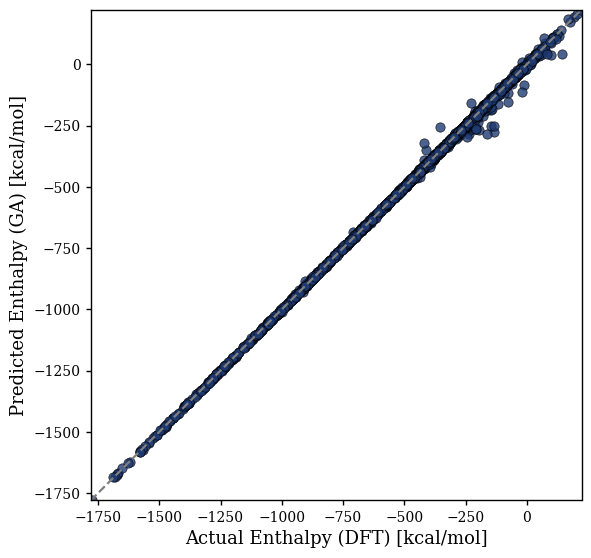

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- ACS/JCIM aesthetic settings ---
plt.rcParams['font.family'] = 'DejaVu Serif'   # professional serif fallback
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0

fig, ax = plt.subplots(figsize=(6, 6))  # square aspect

# --- Scatter points ---
ax.scatter(
    all_y_test_enthalpy,
    all_y_pred_enthalpy,
    s=45,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    color='#1f3b73'   # deep blue, ACS‑friendly
)

# --- 1:1 line ---
min_val = min(all_y_test_enthalpy.min(), all_y_pred_enthalpy.min())
max_val = max(all_y_test_enthalpy.max(), all_y_pred_enthalpy.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    color='#7f7f7f',
    linewidth=1.6
)

# --- Labels ---
ax.set_xlabel('Actual Enthalpy (DFT) [kcal/mol]', fontsize=13)
ax.set_ylabel('Predicted Enthalpy (GA) [kcal/mol]', fontsize=13)

# --- Clean aesthetic ---
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_aspect('equal', adjustable='box')
ax.grid(False)

plt.tight_layout()

# --- Save as SVG (vector graphic, ACS‑friendly) ---
plt.savefig("parity_plot_enthalpy.svg", format="svg")

plt.show()

In [12]:
# --- Import required libraries ---
# pandas/numpy for data handling, sklearn for cross‑validation, scipy for Grubbs' test
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import t

# --- Function: Iterative Grubbs' test for outlier removal ---
# Removes one statistical outlier at a time until no further outliers remain
def remove_outliers_grubbs(values, smiles_list, alpha=0.05):
    values = np.array(values)
    smiles_list = np.array(smiles_list)
    outliers = []

    while True:
        n = len(values)
        if n < 3:  # Grubbs' test requires at least 3 points
            break

        mean = np.mean(values)
        std = np.std(values, ddof=1)

        # Compute Grubbs statistic
        G = max(abs(values - mean)) / std

        # Compute critical threshold for significance
        t_crit = t.ppf(1 - alpha / (2 * n), n - 2)
        G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))

        # Remove the largest outlier if significant
        if G > G_crit:
            idx = np.argmax(abs(values - mean))
            outliers.append((smiles_list[idx], values[idx]))
            values = np.delete(values, idx)
            smiles_list = np.delete(smiles_list, idx)
        else:
            break

    return values, smiles_list, outliers


# --- Load group matrix ---
# Read group matrix CSV and normalize SMILES index formatting
group_matrix_df = pd.read_csv("group_matrix_new.csv", index_col=0)
group_matrix_df.index = group_matrix_df.index.astype(str).str.strip()

# --- Load DFT entropy data ---
# Read StatMech entropies and map SMILES → entropy
dft_data_test_df = pd.read_csv("DFT_Data_StatMech_new.csv")
dft_data_test_df["SMILES"] = dft_data_test_df["SMILES"].astype(str).str.strip()
entropy_dict_test = dict(zip(dft_data_test_df["SMILES"], dft_data_test_df["Entropy"]))

# --- Filter molecules present in both datasets ---
valid_molecules_test = [mol for mol in group_matrix_df.index if mol in entropy_dict_test]

# Extract entropy values and SMILES arrays
entropy_values_raw = np.array([entropy_dict_test[mol] for mol in valid_molecules_test], dtype=float)
smiles_raw = np.array(valid_molecules_test)

# --- Remove outliers using Grubbs' test ---
entropy_values_test, smiles_filtered, outliers = remove_outliers_grubbs(
    entropy_values_raw, smiles_raw
)

# --- Filter group matrix to only include non‑outlier molecules ---
group_matrix_test_df = group_matrix_df.loc[smiles_filtered]
group_matrix_test = group_matrix_test_df.values

# --- Set up 10‑fold cross‑validation ---
kf_test = KFold(n_splits=10, shuffle=True, random_state=42)
rmse_list_test = []
y_test_entropy = []
y_pred_entropy = []
all_smiles = []

# --- Perform cross‑validation ---
for fold, (train_index, test_index) in enumerate(kf_test.split(group_matrix_test), 1):
    # Split group matrix and entropy values
    x_train = group_matrix_test[train_index]
    y_train = entropy_values_test[train_index]
    x_test = group_matrix_test[test_index]
    y_test = entropy_values_test[test_index]
    smiles_test_fold = smiles_filtered[test_index]

    # Compute group contributions using pseudoinverse regression
    pseudo_inverse_train = np.linalg.pinv(x_train)
    group_mean_values_fold = np.dot(pseudo_inverse_train, y_train)

    # Predict entropies for test fold
    y_pred = np.dot(x_test, group_mean_values_fold)

    # Compute RMSE for this fold
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_list_test.append(rmse)

    # Store predictions and actual values
    y_test_entropy.append(y_test)
    y_pred_entropy.append(y_pred)
    all_smiles.extend(smiles_test_fold)

    print(f"Fold {fold}: RMSE = {rmse:.4f}")

# --- Final cross‑validation metrics ---
average_rmse_test = np.mean(rmse_list_test)
print(f"\nAverage RMSE across all folds: {average_rmse_test:.4f}")

# Compute overall RMSE across all folds combined
all_y_test_entropy = np.concatenate(y_test_entropy)
all_y_pred_entropy = np.concatenate(y_pred_entropy)
total_rmse_test = np.sqrt(np.mean((all_y_test_entropy - all_y_pred_entropy) ** 2))
print(f"Total RMSE across all folds: {total_rmse_test:.4f}")

# --- Build DataFrame of predictions ---
results_df = pd.DataFrame({
    "SMILES": all_smiles,
    "Predicted_Entropy": all_y_pred_entropy,
    "Actual_Entropy": all_y_test_entropy
})

# Add molecule names if available in DFT dataset
if "Name" in dft_data_test_df.columns:
    name_dict = dict(zip(dft_data_test_df["SMILES"], dft_data_test_df["Name"]))
    results_df["Name"] = results_df["SMILES"].map(name_dict)
    results_df = results_df[["Name", "SMILES", "Predicted_Entropy", "Actual_Entropy"]]
else:
    results_df = results_df[["SMILES", "Predicted_Entropy", "Actual_Entropy"]]

# --- Save predictions to CSV ---
results_df.to_csv("predicted_vs_actual_entropies.csv", index=False)
print("\nSaved predictions to 'predicted_vs_actual_entropies.csv'")


Fold 1: RMSE = 10.3743
Fold 2: RMSE = 10.2852
Fold 3: RMSE = 8.8677
Fold 4: RMSE = 10.8096
Fold 5: RMSE = 9.0267
Fold 6: RMSE = 9.2339
Fold 7: RMSE = 9.6866
Fold 8: RMSE = 10.0246
Fold 9: RMSE = 10.1088
Fold 10: RMSE = 11.7645

Average RMSE across all folds: 10.0182
Total RMSE across all folds: 10.0524

Saved predictions to 'predicted_vs_actual_entropies.csv'


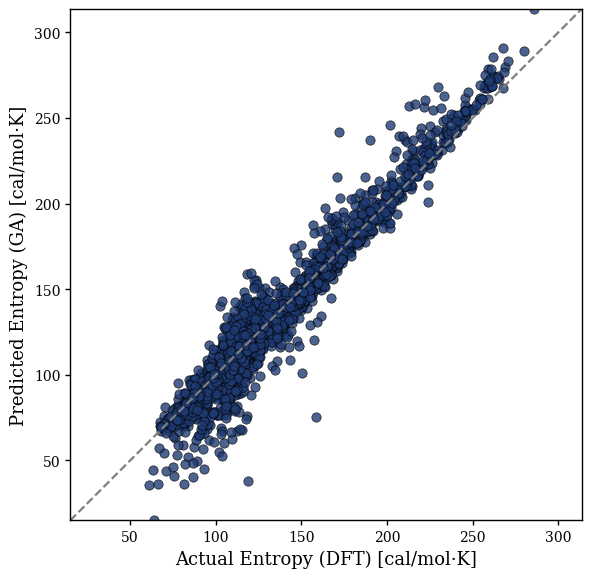

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- ACS/JCIM aesthetic settings ---
plt.rcParams['font.family'] = 'DejaVu Serif'   # professional serif fallback
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0

fig, ax = plt.subplots(figsize=(6, 6))  # square aspect

# --- Scatter points ---
ax.scatter(
    all_y_test_entropy,
    all_y_pred_entropy,
    s=45,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    color='#1f3b73'   # deep blue, ACS‑friendly
)

# --- 1:1 line ---
min_val = min(all_y_test_entropy.min(), all_y_pred_entropy.min())
max_val = max(all_y_test_entropy.max(), all_y_pred_entropy.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    color='#7f7f7f',
    linewidth=1.6
)

# --- Labels ---
ax.set_xlabel('Actual Entropy (DFT) [cal/mol·K]', fontsize=13)
ax.set_ylabel('Predicted Entropy (GA) [cal/mol·K]', fontsize=13)

# --- Clean aesthetic ---
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_aspect('equal', adjustable='box')
ax.grid(False)

plt.tight_layout()

# --- Save as SVG (vector graphic, ACS‑friendly) ---
plt.savefig("entropy_parity_plot.svg", format="svg")

plt.show()

In [14]:
# --- Import required libraries ---
# pandas/numpy for data handling, sklearn for cross‑validation, scipy for Grubbs' test
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import t

# --- Function: Iterative Grubbs' test for outlier removal ---
# Removes one statistical outlier at a time until no further outliers remain
def remove_outliers_grubbs(values, smiles_list, alpha=0.05):
    values = np.array(values)
    smiles_list = np.array(smiles_list)
    outliers = []

    while True:
        n = len(values)
        if n < 3:  # Grubbs' test requires at least 3 points
            break

        mean = np.mean(values)
        std = np.std(values, ddof=1)

        # Compute Grubbs statistic
        G = max(abs(values - mean)) / std

        # Compute critical threshold for significance
        t_crit = t.ppf(1 - alpha / (2 * n), n - 2)
        G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))

        # Remove the largest outlier if significant
        if G > G_crit:
            idx = np.argmax(abs(values - mean))
            outliers.append((smiles_list[idx], values[idx]))
            values = np.delete(values, idx)
            smiles_list = np.delete(smiles_list, idx)
        else:
            break

    return values, smiles_list, outliers


# --- Load group matrix ---
# Read group matrix CSV and normalize SMILES index formatting
group_matrix_df = pd.read_csv("group_matrix_new.csv", index_col=0)
group_matrix_df.index = group_matrix_df.index.astype(str).str.strip()

# Remove any duplicated SMILES entries (keep first occurrence)
group_matrix_df = group_matrix_df[~group_matrix_df.index.duplicated(keep='first')]

# --- Load heat capacity data ---
# Read StatMech Cp(T) values and normalize SMILES formatting
heat_capacity_df = pd.read_csv("DFT_Data_StatMech_new.csv")
heat_capacity_df["SMILES"] = heat_capacity_df["SMILES"].astype(str).str.strip()
heat_capacity_df.set_index("SMILES", inplace=True)

# Remove duplicated SMILES entries
heat_capacity_df = heat_capacity_df[~heat_capacity_df.index.duplicated(keep='first')]

# --- Align datasets by SMILES ---
# Only keep molecules present in both datasets
valid_molecules = sorted(set(group_matrix_df.index) & set(heat_capacity_df.index))
group_matrix_df = group_matrix_df.loc[valid_molecules]
heat_capacity_df = heat_capacity_df.loc[valid_molecules]

# --- Identify Cp(T) columns ---
cp_columns = [col for col in heat_capacity_df.columns if col.startswith("Cp_")]

# Convert group matrix to numpy array for modeling
group_matrix = group_matrix_df.values

# Optional: map SMILES → molecule name if available
name_dict = heat_capacity_df["Name"].to_dict() if "Name" in heat_capacity_df.columns else {}

# --- Loop over each Cp temperature column ---
for temp in cp_columns:

    # Extract Cp values and SMILES arrays
    cp_values_raw = heat_capacity_df[temp].astype(float).values
    smiles_raw = np.array(valid_molecules)

    # --- Remove outliers using Grubbs' test ---
    cp_values, smiles_filtered, outliers = remove_outliers_grubbs(cp_values_raw, smiles_raw)

    # Filter group matrix to match filtered SMILES
    group_matrix_filtered = group_matrix_df.loc[smiles_filtered].values

    # --- Set up 10‑fold cross‑validation ---
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    rmse_list = []
    y_test_all = []
    y_pred_all = []
    smiles_all = []

    # --- Perform cross‑validation ---
    for fold, (train_index, test_index) in enumerate(kf.split(group_matrix_filtered), 1):
        # Split group matrix and Cp values
        x_train = group_matrix_filtered[train_index]
        y_train = cp_values[train_index]
        x_test = group_matrix_filtered[test_index]
        y_test = cp_values[test_index]
        smiles_fold = smiles_filtered[test_index]

        # Compute group contributions using pseudoinverse regression
        pseudo_inverse = np.linalg.pinv(x_train)
        group_mean_values = np.dot(pseudo_inverse, y_train)

        # Predict Cp for test fold
        y_pred = np.dot(x_test, group_mean_values)

        # Compute RMSE for this fold
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmse_list.append(rmse)

        # Store predictions and actual values
        y_test_all.append(y_test)
        y_pred_all.append(y_pred)
        smiles_all.extend(smiles_fold)

        print(f"{temp} - Fold {fold}: RMSE = {rmse:.4f}")

    # --- Final cross‑validation metrics ---
    avg_rmse = np.mean(rmse_list)
    total_rmse = np.sqrt(np.mean((np.concatenate(y_test_all) - np.concatenate(y_pred_all)) ** 2))

    print(f"\n{temp} - Average RMSE: {avg_rmse:.4f}")
    print(f"{temp} - Total RMSE across all folds: {total_rmse:.4f}")

    # --- Build DataFrame of predictions ---
    results_df = pd.DataFrame({
        "SMILES": smiles_all,
        "Predicted_Cp": np.concatenate(y_pred_all),
        "Actual_Cp": np.concatenate(y_test_all),
        "Temperature": temp
    })

    # Add molecule names if available
    if name_dict:
        results_df["Name"] = results_df["SMILES"].map(name_dict)
        results_df = results_df[["Name", "SMILES", "Temperature", "Predicted_Cp", "Actual_Cp"]]
    else:
        results_df = results_df[["SMILES", "Temperature", "Predicted_Cp", "Actual_Cp"]]

    # --- Save predictions to CSV ---
    results_df.to_csv(f"predicted_vs_actual_{temp}.csv", index=False)
    print(f"Saved predictions to 'predicted_vs_actual_{temp}.csv'\n")


Cp_300 - Fold 1: RMSE = 0.9670
Cp_300 - Fold 2: RMSE = 0.9353
Cp_300 - Fold 3: RMSE = 1.0013
Cp_300 - Fold 4: RMSE = 1.1603
Cp_300 - Fold 5: RMSE = 1.2268
Cp_300 - Fold 6: RMSE = 1.1467
Cp_300 - Fold 7: RMSE = 1.3840
Cp_300 - Fold 8: RMSE = 0.9413
Cp_300 - Fold 9: RMSE = 1.1586
Cp_300 - Fold 10: RMSE = 0.9014

Cp_300 - Average RMSE: 1.0823
Cp_300 - Total RMSE across all folds: 1.0924
Saved predictions to 'predicted_vs_actual_Cp_300.csv'

Cp_400 - Fold 1: RMSE = 1.1342
Cp_400 - Fold 2: RMSE = 1.1053
Cp_400 - Fold 3: RMSE = 1.0797
Cp_400 - Fold 4: RMSE = 1.2712
Cp_400 - Fold 5: RMSE = 1.3959
Cp_400 - Fold 6: RMSE = 1.2906
Cp_400 - Fold 7: RMSE = 1.5290
Cp_400 - Fold 8: RMSE = 1.0638
Cp_400 - Fold 9: RMSE = 1.3339
Cp_400 - Fold 10: RMSE = 0.9702

Cp_400 - Average RMSE: 1.2174
Cp_400 - Total RMSE across all folds: 1.2286
Saved predictions to 'predicted_vs_actual_Cp_400.csv'

Cp_500 - Fold 1: RMSE = 1.2704
Cp_500 - Fold 2: RMSE = 1.2525
Cp_500 - Fold 3: RMSE = 1.1513
Cp_500 - Fold 4: RMSE =

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import t
from ruamel.yaml import YAML
from ruamel.yaml.comments import CommentedSeq

# Grubbs' test for outlier removal
def remove_outliers_grubbs(values, smiles_list, alpha=0.05):
    values = np.array(values)
    smiles_list = np.array(smiles_list)
    outliers = []

    while True:
        n = len(values)
        if n < 3:
            break
        mean = np.mean(values)
        std = np.std(values, ddof=1)
        G = max(abs(values - mean)) / std
        t_crit = t.ppf(1 - alpha / (2 * n), n - 2)
        G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))

        if G > G_crit:
            idx = np.argmax(abs(values - mean))
            outliers.append((smiles_list[idx], values[idx]))
            values = np.delete(values, idx)
            smiles_list = np.delete(smiles_list, idx)
        else:
            break

    return values, smiles_list, outliers

# Load group matrix
group_matrix_df = pd.read_csv("group_matrix_new.csv", index_col=0)
group_matrix_df.index = group_matrix_df.index.astype(str).str.strip()

# Load DFT data
dft_data_df = pd.read_csv("DFT_Data_StatMech_new.csv")
dft_data_df["SMILES"] = dft_data_df["SMILES"].astype(str).str.strip()
dft_data_df.set_index("SMILES", inplace=True)

# Remove duplicates
group_matrix_df = group_matrix_df[~group_matrix_df.index.duplicated(keep='first')]
dft_data_df = dft_data_df[~dft_data_df.index.duplicated(keep='first')]

# Align molecules
valid_molecules = sorted(set(group_matrix_df.index) & set(dft_data_df.index))
group_matrix_df = group_matrix_df.loc[valid_molecules]
dft_data_df = dft_data_df.loc[valid_molecules]

# Extract raw values
smiles_raw = np.array(valid_molecules)
enthalpy_raw = dft_data_df["Enthalpy"].astype(float).values
entropy_raw = dft_data_df["Entropy"].astype(float).values
cp_columns = [col for col in dft_data_df.columns if col.startswith("Cp_")]
cp_data_raw = dft_data_df[cp_columns].astype(float)

# Apply Grubbs' test
enthalpy_filtered, smiles_filtered, _ = remove_outliers_grubbs(enthalpy_raw, smiles_raw)
entropy_filtered = dft_data_df.loc[smiles_filtered, "Entropy"].astype(float).values
cp_data_filtered = dft_data_df.loc[smiles_filtered, cp_columns].astype(float)
group_matrix_filtered = group_matrix_df.loc[smiles_filtered].values

# Compute group contributions
pseudo_inverse = np.linalg.pinv(group_matrix_filtered)
group_enthalpy = np.dot(pseudo_inverse, enthalpy_filtered)
group_entropy = np.dot(pseudo_inverse, entropy_filtered)
group_cp = {
    int(col.split("_")[1]): np.dot(pseudo_inverse, cp_data_filtered[col].values)
    for col in cp_columns
}

# Build YAML structure
yaml_data = {
    "units": {
        "molar enthalpy": "kcal/mol",
        "molar entropy": "cal/(mol*K)",
        "molar heat capacity": "cal/(mol*K)",
        "temperature": "K"
    },
    "groups": {}
}

# Fill group data
for i, group in enumerate(group_matrix_df.columns):
    cp_list_raw = [[int(temp), round(float(group_cp[temp][i]), 2)] for temp in sorted(group_cp)]

    cp_seq = CommentedSeq()
    for pair in cp_list_raw:
        item = CommentedSeq(pair)
        item.fa.set_flow_style()
        cp_seq.append(item)

    yaml_data["groups"][group] = {
        "thermochem": {
            "T_ref": 298.0,
            "H_ref": round(float(group_enthalpy[i]), 2),
            "S_ref": round(float(group_entropy[i]), 2),
            "Cp_data": cp_seq,
            "range": CommentedSeq([298, 1500])
        }
    }

# Configure ruamel.yaml
yaml = YAML()
yaml.indent(mapping=2, sequence=4, offset=2)
yaml.default_flow_style = None

# Write YAML
with open("NEWgroups.yaml", "w") as f:
    yaml.dump(yaml_data, f)

print("YAML file 'NEWgroups.yaml' created.")


YAML file 'NEWgroups.yaml' created.
